# Cross-Sectional Short-Term Reversal — Backtest & Graphs

This notebook loads the reversal backtest, runs it, and produces the graphs
you'd actually want for a stat-arb writeup:

1. Cumulative gross vs. net return
2. Drawdown curve
3. Rolling turnover
4. Distribution of the cross-sectional signal
5. Strategy return vs. market return scatter (factor exposure check)
6. Signal decay across lookback horizons (bonus)

**Setup**: put `reversal_backtest.py` in the same folder as this notebook.
Requires: `yfinance`, `pandas`, `numpy`, `matplotlib`.
```
pip install yfinance pandas numpy matplotlib
```


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import reversal_backtest as rb

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Get data

Set `USE_SYNTHETIC = False` to pull real prices via `yfinance` (needs internet).
Leave it `True` to instantly test the notebook with simulated data that has a
known, engineered reversal effect baked in — useful for confirming the plots
and pipeline work before waiting on a real download or debugging a small
universe.

In [40]:
USE_SYNTHETIC = False  # flip to False once you have internet access to Yahoo Finance

if USE_SYNTHETIC:
    np.random.seed(42)
    n_days, n_names = 1500, 30  # extra history needed for the 252-day momentum lookback later
    dates = pd.bdate_range("2020-01-01", periods=n_days)
    tickers = [f"T{i:02d}" for i in range(n_names)]

    # Regime-varying vol path: mostly calm (~12% annualized), with two sharp
    # spike episodes (~55% annualized) lasting ~25 trading days each, loosely
    # mimicking a tariff-shock-style event. During spikes the idiosyncratic
    # AR(1) coefficient flips sign (continuation instead of reversal) --
    # modeling the hypothesis that crisis moves are information-driven, not
    # liquidity-driven, and the reversal effect can break down.
    base_vol = np.full(n_days, 0.12)
    for s in [300, 700, 1100]:
        length = 25
        path = np.concatenate([np.linspace(0.12, 0.55, 8),
                                np.full(length - 16, 0.55),
                                np.linspace(0.55, 0.15, 8)])
        base_vol[s:s + len(path)] = path
    daily_vol = base_vol / np.sqrt(252)

    market_ret = np.random.normal(0.0002, 1, n_days) * daily_vol

    # Slow per-name drift regime (persists ~250 days, then shifts) -- gives
    # momentum a genuine multi-month trend to detect, independent of the
    # fast mean-reverting component below.
    trend = np.zeros((n_days, n_names))
    drift = np.random.normal(0, 0.0004, n_names)
    for t in range(1, n_days):
        if t % 250 == 0:
            drift = np.random.normal(0, 0.0004, n_names)
        trend[t] = drift

    # Fast idiosyncratic mean-reverting component (reversal source), with the
    # sign flip during vol spikes described above.
    idio = np.zeros((n_days, n_names))
    phi_calm, phi_spike = -0.06, 0.10
    for t in range(1, n_days):
        phi_t = phi_spike if base_vol[t] > 0.30 else phi_calm
        idio[t] = phi_t * idio[t - 1] + np.random.normal(0, 1, n_names) * daily_vol[t]

    returns_df = pd.DataFrame(trend + idio + market_ret[:, None], index=dates, columns=tickers)
    close = 100 * (1 + returns_df).cumprod()
    volume = pd.DataFrame(np.random.uniform(1e6, 5e6, size=(n_days, n_names)),
                           index=dates, columns=tickers)
else:
    tickers = [
        "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "V", "UNH",
        "HD", "PG", "MA", "DIS", "BAC", "XOM", "PFE", "KO", "PEP", "CSCO",
        "INTC", "T", "VZ", "ABT", "CRM", "NKE", "MRK", "WMT", "MCD", "ADBE",
    ]
    close, volume = rb.download_universe(tickers, rb.CONFIG["start_date"], rb.CONFIG["end_date"])

print(f"Universe: {close.shape[1]} names, {close.shape[0]} trading days")
close.tail()


Universe: 30 names, 2516 trading days


,AAPL,MSFT,AMZN,GOOGL,META,NVDA,TSLA,JPM,V,UNH,...,INTC,T,VZ,ABT,CRM,NKE,MRK,WMT,MCD,ADBE
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,434.179352,229.050003,195.090988,604.760742,140.174088,462.279999,233.964600,317.076080,487.342163,...,20.400000,21.486578,36.058937,111.359657,340.463562,74.532799,94.462715,91.438759,285.693115,447.940002
2024-12-26,257.375549,432.973663,227.050003,194.583664,600.382507,139.884171,454.130005,234.765991,317.333191,492.205017,...,20.440001,21.495939,36.203903,111.854546,337.784821,74.678383,94.861664,91.547287,286.480255,450.160004
2024-12-27,253.967392,425.482513,223.750000,191.758408,596.859863,136.965103,431.660004,232.863861,315.108276,491.087982,...,20.299999,21.402315,36.167660,111.582832,334.552521,74.173660,94.700180,90.432419,285.333588,446.480011
2024-12-30,250.598892,419.849365,221.300003,190.246307,588.331970,137.444962,417.410004,231.077606,311.795624,488.979156,...,19.820000,21.168257,35.877735,109.457741,331.873688,72.455704,93.436890,89.357018,281.427063,445.799988
2024-12-31,248.830200,416.558411,219.389999,188.316391,582.630188,134.246017,403.839996,231.454163,312.517487,487.111023,...,20.049999,21.318056,36.231079,109.758553,330.479858,73.445717,94.491219,89.139954,281.708862,444.679993


## 2. Run the backtest

In [41]:
results, weights, signal_z = rb.run_backtest(close, volume, rb.CONFIG)

market_ret = close.pct_change().mean(axis=1)
summary = rb.performance_summary(results)
factor_stats = rb.factor_decomposition(results, market_ret)

print("=== Performance Summary ===")
print(summary.round(4))
print("\n=== Factor Decomposition ===")
for k, v in factor_stats.items():
    print(f"{k}: {v:.5f}")


=== Performance Summary ===
Gross Ann. Return       -0.0205
Net Ann. Return         -0.3490
Gross Sharpe            -0.0931
Net Sharpe              -1.5864
Avg Daily Turnover       2.8618
Avg Daily Cost (bps)    13.0367
Max Drawdown (net)      -0.9760
Max Drawdown (gross)    -0.6125
dtype: float64

=== Factor Decomposition ===
alpha_daily: -0.00146
alpha_annualized: -0.36913
beta_mkt: 0.10541


## 3. Cumulative return: gross vs. net

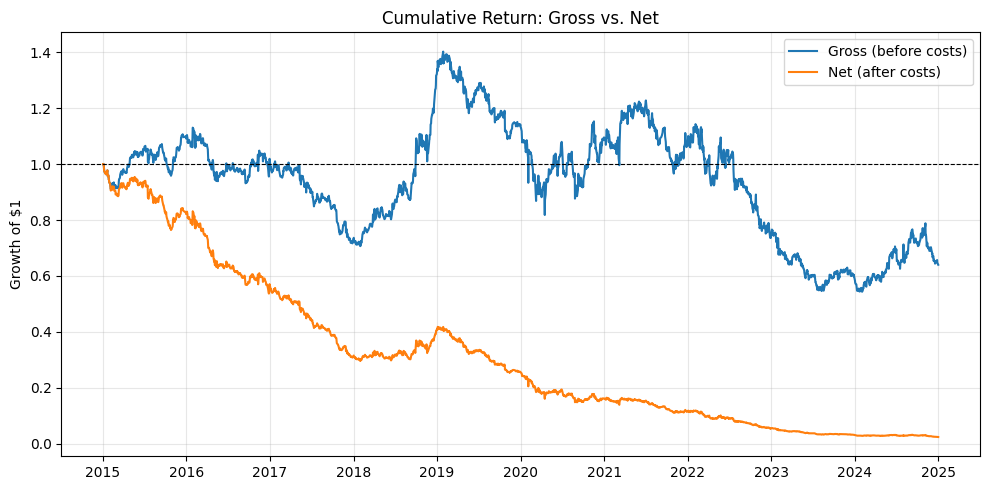

In [42]:
cum_gross = (1 + results["gross_ret"]).cumprod()
cum_net = (1 + results["net_ret"]).cumprod()

fig, ax = plt.subplots()
ax.plot(cum_gross.index, cum_gross.values, label="Gross (before costs)", linewidth=1.5)
ax.plot(cum_net.index, cum_net.values, label="Net (after costs)", linewidth=1.5)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return: Gross vs. Net")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Drawdown curve (net)

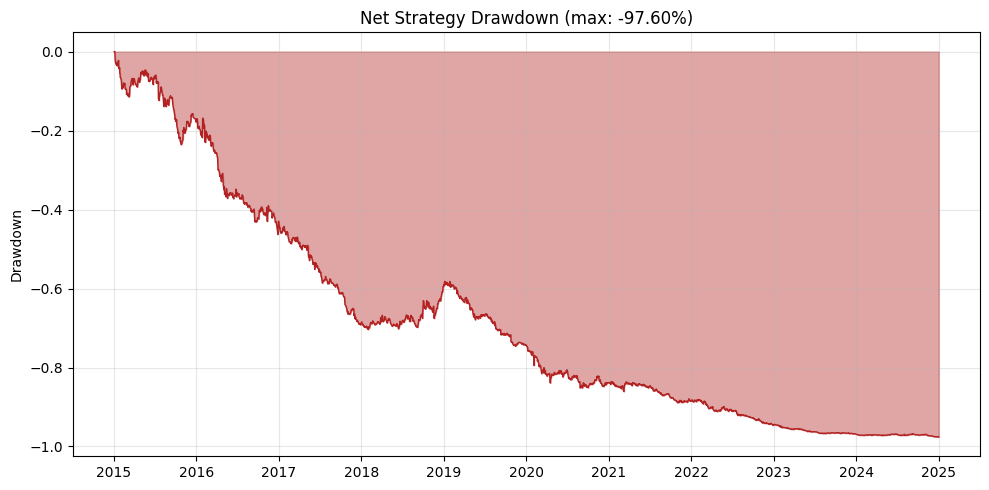

In [43]:
running_max = cum_net.cummax()
drawdown = cum_net / running_max - 1

fig, ax = plt.subplots()
ax.fill_between(drawdown.index, drawdown.values, 0, color="firebrick", alpha=0.4)
ax.plot(drawdown.index, drawdown.values, color="firebrick", linewidth=1)
ax.set_title(f"Net Strategy Drawdown (max: {drawdown.min():.2%})")
ax.set_ylabel("Drawdown")
plt.tight_layout()
plt.show()


## 5. Rolling turnover and cost drag

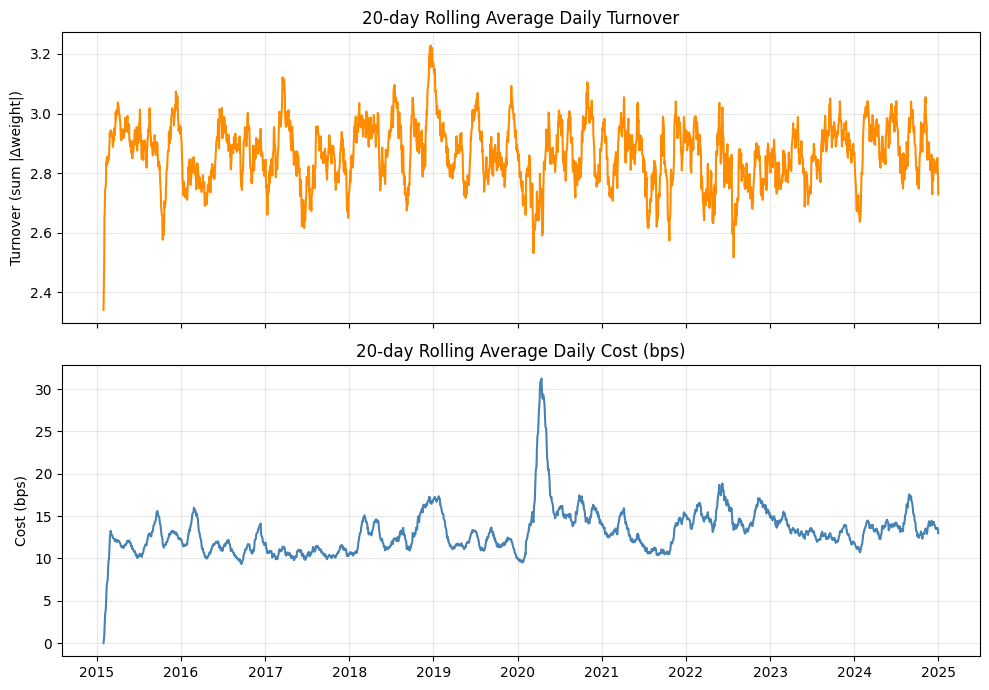

In [44]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

axes[0].plot(results.index, results["turnover"].rolling(20).mean(), color="darkorange")
axes[0].set_title("20-day Rolling Average Daily Turnover")
axes[0].set_ylabel("Turnover (sum |Δweight|)")

axes[1].plot(results.index, (results["cost"] * 1e4).rolling(20).mean(), color="steelblue")
axes[1].set_title("20-day Rolling Average Daily Cost (bps)")
axes[1].set_ylabel("Cost (bps)")

plt.tight_layout()
plt.show()


## 6. Cross-sectional signal distribution

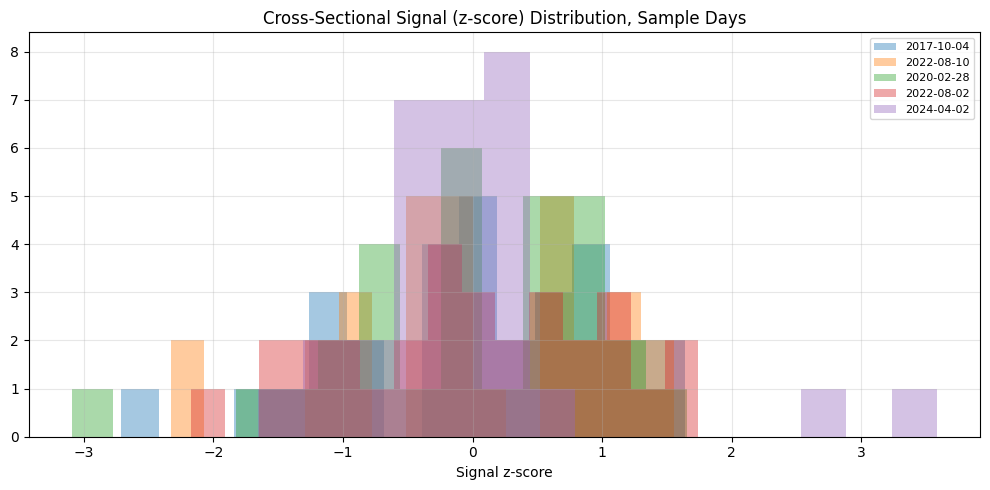

In [45]:
fig, ax = plt.subplots()
sample_days = signal_z.dropna(how="all").sample(min(5, signal_z.shape[0]), random_state=1)
for dt, row in sample_days.iterrows():
    ax.hist(row.dropna(), bins=15, alpha=0.4, label=str(dt.date()))
ax.set_title("Cross-Sectional Signal (z-score) Distribution, Sample Days")
ax.set_xlabel("Signal z-score")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Factor exposure check: strategy return vs. market return

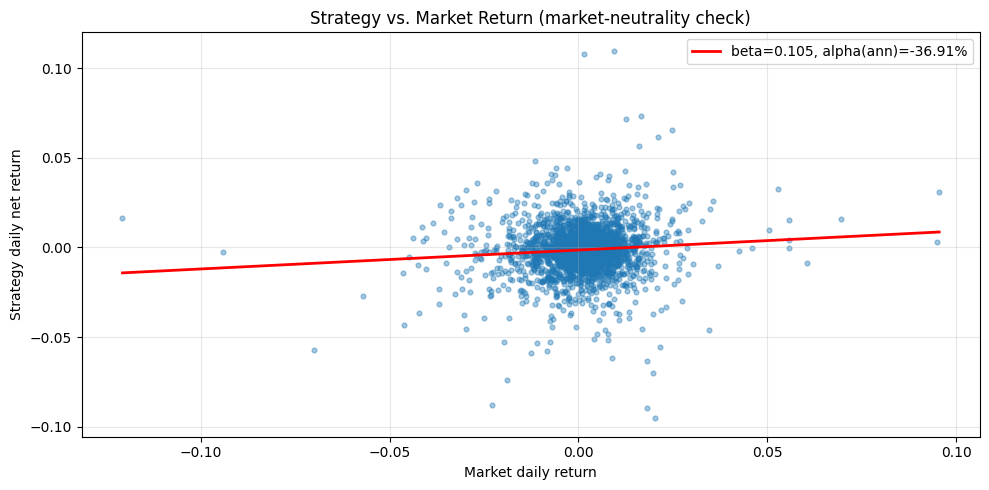

In [46]:
df = pd.concat([results["net_ret"], market_ret], axis=1).dropna()
df.columns = ["strategy", "market"]

fig, ax = plt.subplots()
ax.scatter(df["market"], df["strategy"], alpha=0.4, s=12)
x = np.linspace(df["market"].min(), df["market"].max(), 50)
ax.plot(x, factor_stats["alpha_daily"] + factor_stats["beta_mkt"] * x,
        color="red", linewidth=2,
        label=f"beta={factor_stats['beta_mkt']:.3f}, alpha(ann)={factor_stats['alpha_annualized']:.2%}")
ax.set_xlabel("Market daily return")
ax.set_ylabel("Strategy daily net return")
ax.set_title("Strategy vs. Market Return (market-neutrality check)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Bonus: signal decay across lookback horizons

Re-runs the backtest at several `lookback` values to see whether the effect
is strongest at 1 day and decays, or holds up further out — a key diagnostic
for whether this is really a short-horizon liquidity effect.

               Gross Sharpe  Net Sharpe  Avg Daily Turnover
lookback_days                                              
1                    -0.093      -1.586               2.862
2                     0.159      -0.882               2.014
3                     0.102      -0.743               1.636
5                    -0.126      -0.772               1.252
10                   -0.149      -0.600               0.869


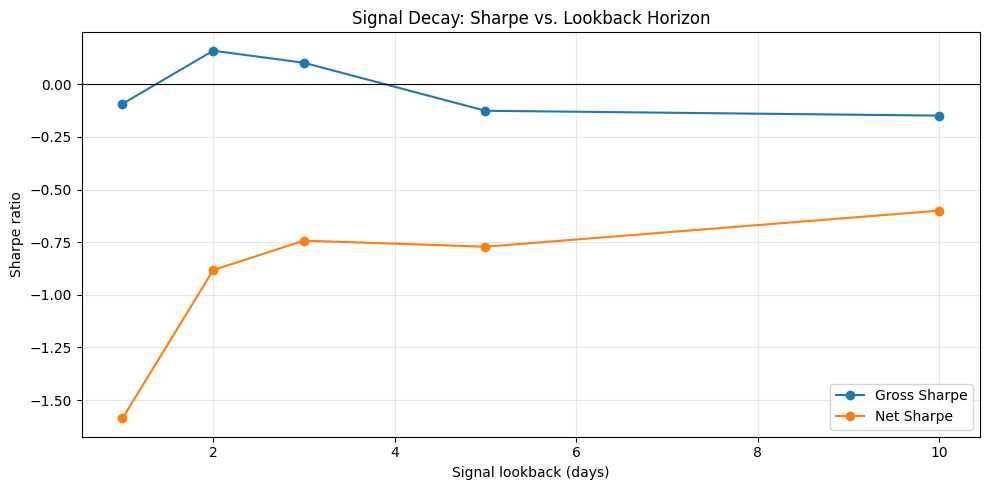

In [47]:
lookbacks = [1, 2, 3, 5, 10]
decay_results = {}

for lb in lookbacks:
    cfg = dict(rb.CONFIG)
    cfg["lookback"] = lb
    res, _, _ = rb.run_backtest(close, volume, cfg)
    decay_results[lb] = rb.performance_summary(res)

decay_df = pd.DataFrame(decay_results).T
decay_df.index.name = "lookback_days"
print(decay_df[["Gross Sharpe", "Net Sharpe", "Avg Daily Turnover"]].round(3))

fig, ax = plt.subplots()
ax.plot(decay_df.index, decay_df["Gross Sharpe"], marker="o", label="Gross Sharpe")
ax.plot(decay_df.index, decay_df["Net Sharpe"], marker="o", label="Net Sharpe")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Signal lookback (days)")
ax.set_ylabel("Sharpe ratio")
ax.set_title("Signal Decay: Sharpe vs. Lookback Horizon")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Volatility regime overlay

Since early 2025, markets have swung between calm stretches and sharp,
event-driven volatility spikes (tariff shocks, AI-valuation jitters, Fed
policy surprises). This section:

1. Classifies each day into a `low` / `medium` / `high` / `extreme` volatility
   regime, based on trailing realized volatility of the universe (or VIX
   itself if you supply it — see `vix=` argument to `run_backtest`).
2. Reports Sharpe/turnover/cost **separately by regime** — this is the key
   diagnostic, since it tells you *which* regimes the signal actually works
   in before you decide how to size around them.
3. Applies a configurable per-regime leverage multiplier
   (`CONFIG["regime_scalars"]`) and compares baseline vs. overlay performance.

**Important**: don't assume "high vol = good for reversal" or "bad for
reversal" up front. Run the by-regime breakdown first, look at which regimes
actually help or hurt on your data, and set `regime_scalars` from that —
otherwise you're just encoding an untested prior into your position sizing.

In [48]:
# Baseline vs. regime-overlay comparison
results_base, weights_base, _ = rb.run_backtest(close, volume, rb.CONFIG, use_regime_overlay=False)
results_reg, weights_reg, _ = rb.run_backtest(close, volume, rb.CONFIG, use_regime_overlay=True)

print("=== Baseline (no overlay) ===")
print(rb.performance_summary(results_base).round(4))
print("\nBy regime:")
by_regime_base = rb.performance_by_regime(results_base)
print(by_regime_base.round(4))

print("\n=== With volatility regime overlay ===")
print(rb.performance_summary(results_reg).round(4))
print("\nBy regime:")
by_regime_overlay = rb.performance_by_regime(results_reg)
print(by_regime_overlay.round(4))


=== Baseline (no overlay) ===
Gross Ann. Return       -0.0205
Net Ann. Return         -0.3490
Gross Sharpe            -0.0931
Net Sharpe              -1.5864
Avg Daily Turnover       2.8618
Avg Daily Cost (bps)    13.0367
Max Drawdown (net)      -0.9760
Max Drawdown (gross)    -0.6125
dtype: float64

By regime:
         n_days  Gross Sharpe  Net Sharpe  Gross Ann. Return  Net Ann. Return  \
low      1629.0       -0.4048     -1.9384            -0.0795          -0.3812   
medium    603.0        0.2862     -1.1418             0.0720          -0.2877   
high      226.0        0.5100     -1.1708             0.1242          -0.2852   
extreme    37.0        1.5170     -0.0599             0.6596          -0.0262   

         Avg Daily Turnover  Avg Daily Cost (bps)  
low                  2.8687               11.9703  
medium               2.8614               14.2740  
high                 2.8682               16.2450  
extreme              2.7982               27.2148  

=== With volatility 

### Visualizing regime classification over time

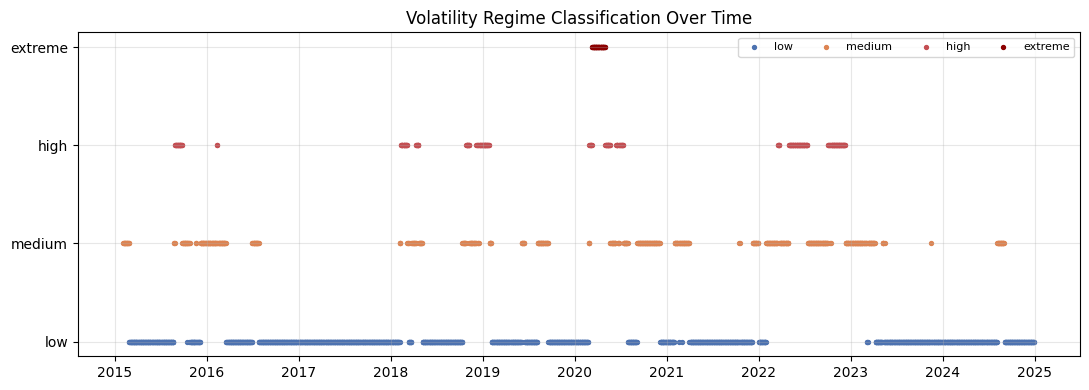

In [49]:
regime_colors = {"low": "#4C72B0", "medium": "#DD8452", "high": "#C44E52", "extreme": "#8C0000"}
regime_order = ["low", "medium", "high", "extreme"]

fig, ax = plt.subplots(figsize=(11, 4))
for i, r in enumerate(regime_order):
    mask = results_base["regime"] == r
    ax.scatter(results_base.index[mask], [i] * mask.sum(),
               color=regime_colors[r], s=8, label=r)
ax.set_yticks(range(len(regime_order)))
ax.set_yticklabels(regime_order)
ax.set_title("Volatility Regime Classification Over Time")
ax.legend(loc="upper right", fontsize=8, ncol=4)
plt.tight_layout()
plt.show()


### Sharpe by regime: baseline vs. overlay

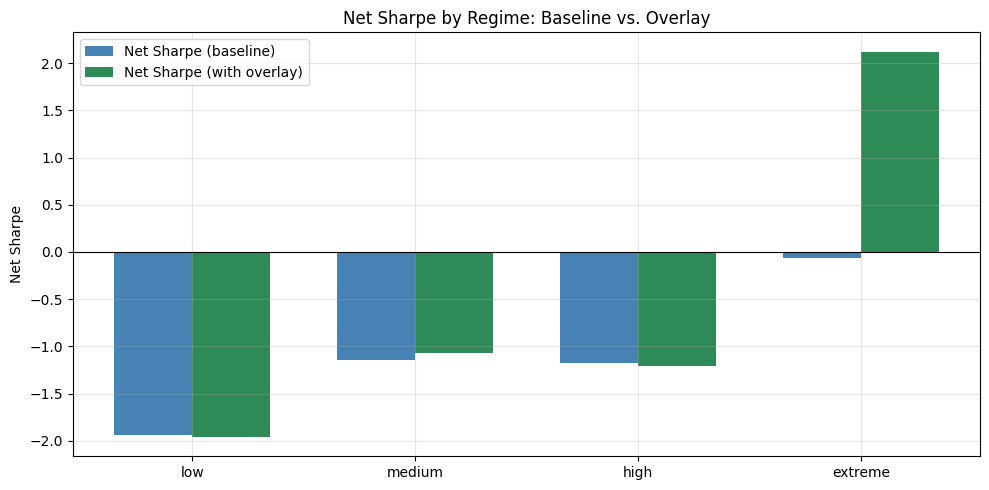

In [50]:
fig, ax = plt.subplots()
idx = np.arange(len(regime_order))
width = 0.35

net_base = [by_regime_base.loc[r, "Net Sharpe"] if r in by_regime_base.index else np.nan for r in regime_order]
net_overlay = [by_regime_overlay.loc[r, "Net Sharpe"] if r in by_regime_overlay.index else np.nan for r in regime_order]

ax.bar(idx - width/2, net_base, width, label="Net Sharpe (baseline)", color="steelblue")
ax.bar(idx + width/2, net_overlay, width, label="Net Sharpe (with overlay)", color="seagreen")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(idx)
ax.set_xticklabels(regime_order)
ax.set_ylabel("Net Sharpe")
ax.set_title("Net Sharpe by Regime: Baseline vs. Overlay")
ax.legend()
plt.tight_layout()
plt.show()


### Cumulative net return: baseline vs. overlay

The overlay should show a visibly smaller drawdown during high/extreme
volatility episodes if it's doing its job — since it cuts exposure exactly
when the regime breakdown above says the signal is struggling.

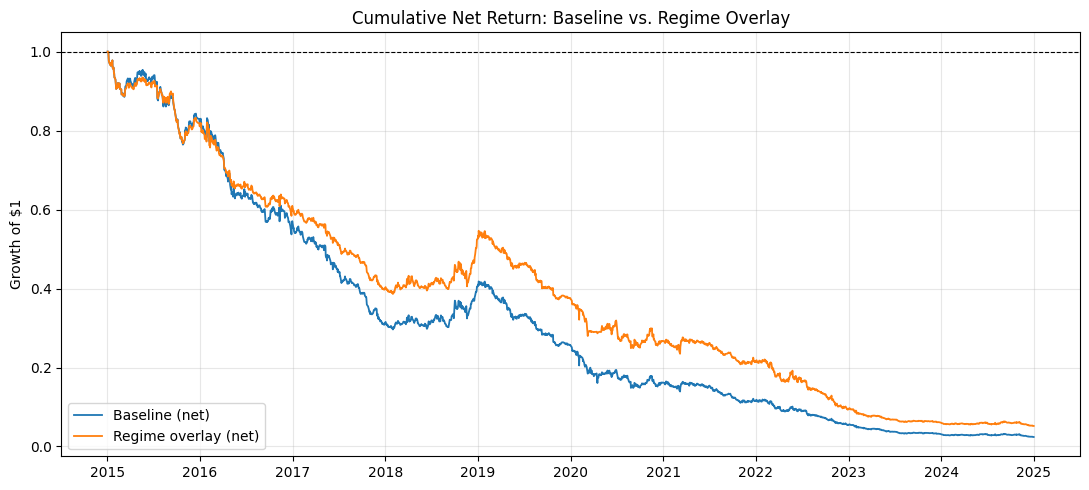

In [51]:
cum_base = (1 + results_base["net_ret"]).cumprod()
cum_overlay = (1 + results_reg["net_ret"]).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cum_base.index, cum_base.values, label="Baseline (net)", linewidth=1.3)
ax.plot(cum_overlay.index, cum_overlay.values, label="Regime overlay (net)", linewidth=1.3)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Net Return: Baseline vs. Regime Overlay")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


### Tuning the regime scalars

Once you've looked at the by-regime Sharpe table above, set
`CONFIG["regime_scalars"]` based on what you actually observed — not a prior.
For example, if `high` turns out harmful in your data too, lower its scalar
rather than leaving it above 1.0.

In [52]:
# Example: re-tune scalars based on the observed regime table, then re-run.
custom_config = dict(rb.CONFIG)
custom_config["regime_scalars"] = {"low": 1.0, "medium": 0.8, "high": 0.3, "extreme": 0.0}

results_custom, _, _ = rb.run_backtest(close, volume, custom_config, use_regime_overlay=True)
print(rb.performance_summary(results_custom).round(4))
print("\nBy regime:")
print(rb.performance_by_regime(results_custom).round(4))


Gross Ann. Return       -0.0399
Net Ann. Return         -0.3157
Gross Sharpe            -0.2121
Net Sharpe              -1.6764
Avg Daily Turnover       2.5045
Avg Daily Cost (bps)    10.9430
Max Drawdown (net)      -0.9642
Max Drawdown (gross)    -0.5837
dtype: float64

By regime:
         n_days  Gross Sharpe  Net Sharpe  Gross Ann. Return  Net Ann. Return  \
low      1629.0       -0.3991     -1.9279            -0.0783          -0.3786   
medium    603.0        0.2046     -1.2093             0.0413          -0.2442   
high      226.0        0.9765     -0.8009             0.0779          -0.0636   
extreme    37.0        2.6098      2.4890             0.0693           0.0642   

         Avg Daily Turnover  Avg Daily Cost (bps)  
low                  2.8566               11.9151  
medium               2.2750               11.3290  
high                 0.9965                5.6145  
extreme              0.0285                0.2024  


## 10. Momentum strategy

Now let's build the other classic anomaly: cross-sectional momentum. Same
pipeline (signal → z-score → dollar-neutral weights → cost model), but:

- **12-month lookback, skip the most recent month** (Jegadeesh-Titman
  convention) — the momentum score is computed on returns from 12 months ago
  to 1 month ago, excluding the most recent month where short-term reversal
  would otherwise contaminate the signal.
- **Volatility-adjusted score** (return / trailing realized vol), so it
  doesn't just chase the most volatile names.
- **Monthly rebalancing** rather than daily — momentum is a much slower
  signal, so daily rebalancing would just generate needless turnover and cost.

`rb.MOMENTUM_CONFIG` has these settings pre-configured; it's a copy of
`rb.CONFIG` with `strategy="momentum"` and the parameters above.

In [53]:
results_mom, weights_mom, signal_mom = rb.run_backtest(close, volume, rb.MOMENTUM_CONFIG)

print("=== Momentum Performance Summary ===")
print(rb.performance_summary(results_mom).round(4))


=== Momentum Performance Summary ===
Gross Ann. Return       0.1076
Net Ann. Return         0.1035
Gross Sharpe            0.5133
Net Sharpe              0.4938
Avg Daily Turnover      0.0365
Avg Daily Cost (bps)    0.1617
Max Drawdown (net)     -0.3106
Max Drawdown (gross)   -0.3061
dtype: float64


### Cumulative return: reversal vs. momentum (both net of cost)

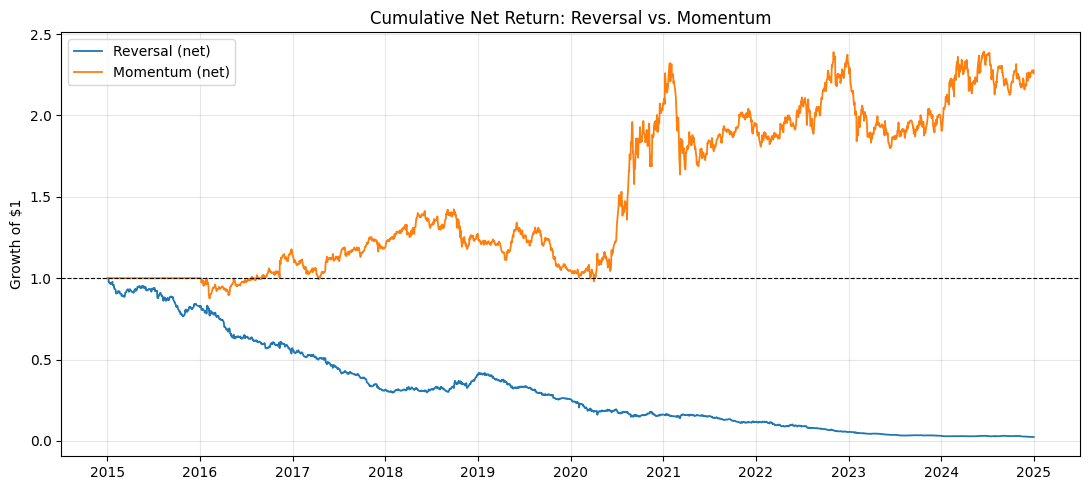

In [54]:
cum_rev = (1 + results_base["net_ret"]).cumprod()
cum_mom = (1 + results_mom["net_ret"]).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cum_rev.index, cum_rev.values, label="Reversal (net)", linewidth=1.3)
ax.plot(cum_mom.index, cum_mom.values, label="Momentum (net)", linewidth=1.3)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Net Return: Reversal vs. Momentum")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Combining the two strategies

Reversal and momentum operate on completely different horizons and
mechanisms (liquidity-driven mean reversion at 1 day vs. behavioral trend
persistence at 12 months), so their return streams should be close to
uncorrelated. If so, **holding both should improve the combined Sharpe
ratio purely through diversification** — even if you don't change either
strategy's own signal at all.

This section:
1. Checks the actual correlation between the two strategies' net daily returns
2. Computes the closed-form Sharpe-maximizing blend weight (tangency portfolio
   on the two return streams)
3. Sweeps the blend weight from 0% to 100% reversal to show the full
   trade-off curve and confirm the closed-form answer against a grid search

In [55]:
strategy_returns = {
    "reversal": results_base["net_ret"],
    "momentum": results_mom["net_ret"],
}

corr = rb.strategy_correlation(strategy_returns)
print("Correlation between strategies (net daily returns):")
print(corr.round(3))

print(f"\nIndividual Sharpe -- reversal: {rb.annualized_sharpe(strategy_returns['reversal']):.3f}, "
      f"momentum: {rb.annualized_sharpe(strategy_returns['momentum']):.3f}")

combined_eq, _ = rb.combine_returns(strategy_returns)  # default: equal weight
print(f"Equal-weight (50/50) blend Sharpe: {rb.annualized_sharpe(combined_eq):.3f}")

opt_weights = rb.max_sharpe_weights(strategy_returns)
combined_opt, _ = rb.combine_returns(strategy_returns, weights=opt_weights)
print(f"\nSharpe-optimal weights: {opt_weights}")
print(f"Optimal blend Sharpe: {rb.annualized_sharpe(combined_opt):.3f}")


Correlation between strategies (net daily returns):
          reversal  momentum
reversal     1.000     0.027
momentum     0.027     1.000

Individual Sharpe -- reversal: -1.586, momentum: 0.494
Equal-weight (50/50) blend Sharpe: -0.797

Sharpe-optimal weights: {'reversal': np.float64(0.0), 'momentum': np.float64(1.0)}
Optimal blend Sharpe: 0.494


### Blend weight sweep: is the optimum a real peak or a coincidence?

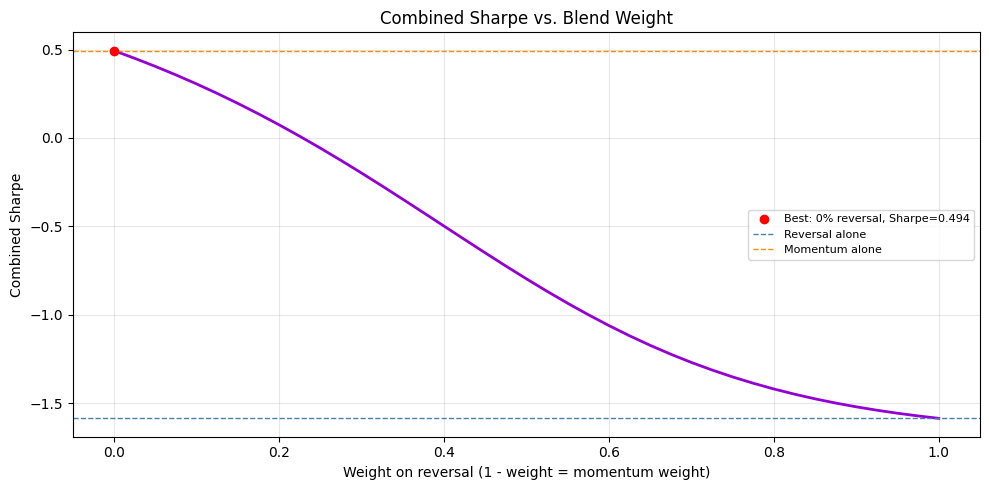

In [56]:
sweep = rb.sweep_blend_weights(strategy_returns, n_points=41)

fig, ax = plt.subplots()
ax.plot(sweep["weight_reversal"], sweep["Sharpe"], linewidth=2, color="darkviolet")
best_row = sweep.loc[sweep["Sharpe"].idxmax()]
ax.scatter([best_row["weight_reversal"]], [best_row["Sharpe"]], color="red", zorder=5,
           label=f"Best: {best_row['weight_reversal']:.0%} reversal, Sharpe={best_row['Sharpe']:.3f}")
ax.axhline(rb.annualized_sharpe(strategy_returns["reversal"]), color="steelblue",
           linestyle="--", linewidth=1, label="Reversal alone")
ax.axhline(rb.annualized_sharpe(strategy_returns["momentum"]), color="darkorange",
           linestyle="--", linewidth=1, label="Momentum alone")
ax.set_xlabel("Weight on reversal (1 - weight = momentum weight)")
ax.set_ylabel("Combined Sharpe")
ax.set_title("Combined Sharpe vs. Blend Weight")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Cumulative return: each strategy alone vs. the optimal blend

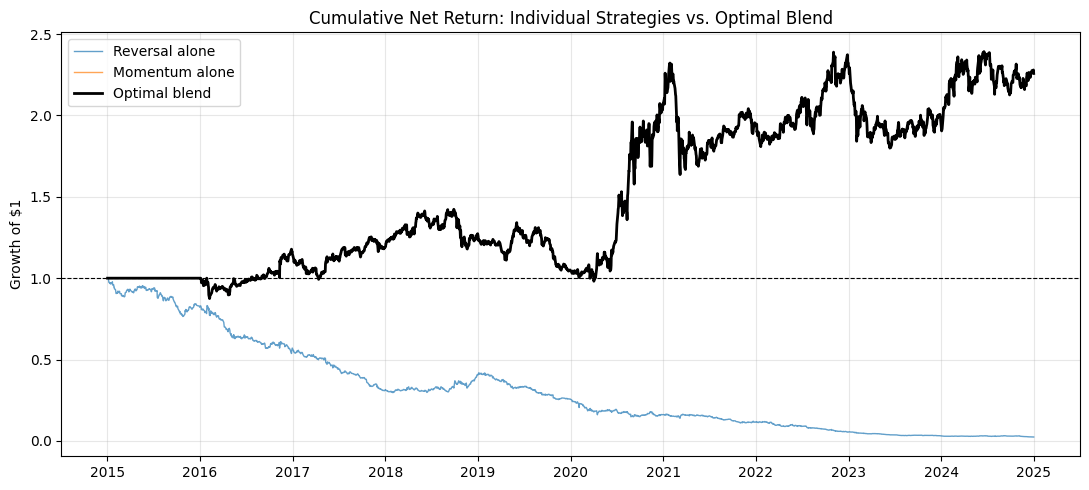

In [57]:
cum_combined = (1 + combined_opt).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cum_rev.index, cum_rev.values, label="Reversal alone", linewidth=1, alpha=0.7)
ax.plot(cum_mom.index, cum_mom.values, label="Momentum alone", linewidth=1, alpha=0.7)
ax.plot(cum_combined.index, cum_combined.values, label="Optimal blend", linewidth=2, color="black")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Net Return: Individual Strategies vs. Optimal Blend")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


### Reading the results

- If the correlation above is close to zero (or negative), the diversification
  benefit is real: the blended Sharpe should exceed **both** individual
  Sharpes, not just be an average of them — that's the tell that you're
  getting something for free (lower risk for the same expected return, or
  vice versa), rather than just picking the better of the two strategies.
- If the blend Sharpe is only ever between the two individual Sharpes (never
  above both), that means the two return streams are too correlated for
  diversification to help — you're just trading off between them, not
  combining them.
- Rerun this section after tuning either strategy's own parameters (e.g. the
  regime overlay from Section 9, or a different momentum lookback) — the
  optimal blend weight and achievable Sharpe will shift as each sleeve's own
  quality changes.